In [1]:
!pip install -q kaggle

import os
os.environ["KAGGLE_USERNAME"] = "birvika"
os.environ["KAGGLE_KEY"] = "15d2dbff346b377b89dab3f99d4fadd4"

!kaggle datasets download -d birvika/laba3go2

Dataset URL: https://www.kaggle.com/datasets/birvika/laba3go2
License(s): unknown
100% 201M/201M [00:15<00:00, 13.7MB/s]



In [2]:
!unzip -o laba3go2.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123190036_01dcc7b9-54ba-42b3-82e7-2b1272a3bbc6_3953590_ip_00011.jpg  
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123193717_9faf1246-49fd-4cb4-9655-05e0d0b1d66f_3953590_ip_00001.jpg  
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123193727_ce082c4c-d775-44e4-9612-39fc8ed9b46a_127_ip_00001.jpg  
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123193727_ce082c4c-d775-44e4-9612-39fc8ed9b46a_127_ip_00011.jpg  
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123202246_158df7a8-7a40-4385-a2a3-adb27325ba22_807_ip_00001.jpg  
  inflating: лаба3_го_3/dl-lab-3-product-segmentation/test_images/10.96.235.111_20260123202253_b235463a-9802-475e-9f89-35877ace6484_197_ip_00011.jpg  
  inflating: лаба3

In [3]:
import torch
print(f"CUDA доступна: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA доступна: True
GPU: NVIDIA A100-SXM4-80GB
Память GPU: 85.1 GB


In [4]:
import os

print("📁 Содержимое после распаковки laba3go2.zip")
print("=" * 60)

# Показываем все файлы и папки в /content
for item in os.listdir('/content'):
    item_path = os.path.join('/content', item)
    if os.path.isdir(item_path):
        print(f"📁 {item}/")
        # Показываем содержимое папки
        try:
            for subitem in os.listdir(item_path)[:5]:
                print(f"   └── {subitem}")
            if len(os.listdir(item_path)) > 5:
                print(f"   └── ... и еще {len(os.listdir(item_path)) - 5} файлов")
        except:
            pass
    else:
        if item.endswith('.zip'):
            print(f"📄 {item} (архив)")
        else:
            print(f"📄 {item}")

📁 Содержимое после распаковки laba3go2.zip
📁 .config/
   └── configurations
   └── default_configs.db
   └── .last_survey_prompt.yaml
   └── active_config
   └── config_sentinel
   └── ... и еще 5 файлов
📁 лаба3_го_3/
   └── dl-lab-3-product-segmentation
📄 laba3go2.zip (архив)
📁 sample_data/
   └── README.md
   └── anscombe.json
   └── california_housing_train.csv
   └── mnist_train_small.csv
   └── california_housing_test.csv
   └── ... и еще 1 файлов


In [5]:
import os

test_dir = "/content/лаба3_го_3/dl-lab-3-product-segmentation/test_images"
if os.path.exists(test_dir):
    images = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png'))]
    print(f"Найдено тестовых изображений: {len(images)}")
    print(f"Путь: {test_dir}")
else:
    print(f"Папка не найдена: {test_dir}")

Найдено тестовых изображений: 2000
Путь: /content/лаба3_го_3/dl-lab-3-product-segmentation/test_images


In [6]:
!pip install segmentation-models-pytorch albumentations pandas opencv-python torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.0 MB/s eta 0:00:00


In [7]:
import os
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple


import albumentations as A
import cv2
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
from albumentations.pytorch import ToTensorV2
from segmentation_models_pytorch.encoders import get_preprocessing_fn
from torch.utils.data import DataLoader, Dataset



CONFIG_BASE: Dict[str, Any] = {
    # "DATA_ROOT": "/content/train",
    "DATA_ROOT": "/content/лаба3_го_3/dl-lab-3-product-segmentation/train",
    "IMAGES_SUBDIR": "images",
    "MASKS_SUBDIR": "masks",
    "SAVE_ROOT": "./seg_train_runs",
    "IMG_SIZE": 512,
    "BATCH_SIZE": 4,
    "NUM_EPOCHS": 80,
    "LR": 3e-4,
    "WEIGHT_DECAY": 1e-4,
    "VAL_RATIO": 0.2,
    "NUM_WORKERS": 2,
    "SEED": 9999,
    "PATIENCE": 15,
    "MODEL_NAME": "FPN",
    "ENCODER_NAME": "timm-efficientnet-b3",
    "ENCODER_WEIGHTS": "imagenet",
    "THRESHOLD": 0.5,
    "BCE_WEIGHT": 0.5,
    "DICE_WEIGHT": 0.5,
    "USE_AMP": True,
    "ALLOW_VERTICAL_FLIP": True,
    "USE_MILD_SHIFT_SCALE_ROTATE": False,
    "ENABLE_COPY_PASTE": False,
    "SCHEDULER_FACTOR": 0.5,
    "SCHEDULER_PATIENCE": 5,
    "RESUME_FROM": None,
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_ROOT = Path(CONFIG_BASE["SAVE_ROOT"])


# =========================
# UTILS (без изменений)
# =========================
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def cv2_imread_unicode(path: Path, flags: int) -> Optional[np.ndarray]:
    data = np.fromfile(str(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)


def find_image_for_stem(images_dir: Path, stem: str) -> Optional[Path]:
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"]:
        candidate = images_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None


def collect_paired_samples(images_dir: Path, masks_dir: Path) -> List[Tuple[Path, Path]]:
    samples: List[Tuple[Path, Path]] = []
    for mask_path in sorted(masks_dir.glob("*.png")):
        image_path = find_image_for_stem(images_dir, mask_path.stem)
        if image_path is not None:
            samples.append((image_path, mask_path))
    if not samples:
        raise RuntimeError(f"No paired samples found in {images_dir} and {masks_dir}")
    return samples


def split_train_val_samples(
    samples: Sequence[Tuple[Path, Path]],
    val_ratio: float,
    seed: int,
) -> Tuple[List[Tuple[Path, Path]], List[Tuple[Path, Path]]]:
    if len(samples) < 2:
        raise ValueError("Need at least 2 samples to make train/val split.")

    val_size = int(len(samples) * val_ratio)
    val_size = max(1, val_size)
    val_size = min(len(samples) - 1, val_size)

    indices = list(range(len(samples)))
    rng = random.Random(seed)
    rng.shuffle(indices)

    val_indices = set(indices[:val_size])
    train_samples = [samples[i] for i in indices if i not in val_indices]
    val_samples = [samples[i] for i in indices if i in val_indices]
    return train_samples, val_samples


def _build_resize_transform(img_size: int) -> A.BasicTransform:
    try:
        return A.Resize(
            img_size,
            img_size,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
        )
    except TypeError:
        return A.Resize(img_size, img_size, interpolation=cv2.INTER_LINEAR)


def build_transforms(
    img_size: int,
    augment: bool,
    allow_vertical_flip: bool,
    use_mild_shift_scale_rotate: bool,
) -> A.Compose:
    transforms: List[A.BasicTransform] = []
    if augment:
        transforms.append(A.HorizontalFlip(p=0.5))
        if allow_vertical_flip:
            transforms.append(A.VerticalFlip(p=0.5))
        transforms.append(A.RandomRotate90(p=0.5))
        if use_mild_shift_scale_rotate:
            transforms.append(
                A.ShiftScaleRotate(
                    shift_limit=0.02,
                    scale_limit=0.05,
                    rotate_limit=10,
                    interpolation=cv2.INTER_LINEAR,
                    border_mode=cv2.BORDER_REFLECT_101,
                    p=0.15,
                )
            )
    transforms.append(_build_resize_transform(img_size))
    transforms.append(ToTensorV2())
    return A.Compose(transforms)


def apply_copy_paste_stub(
    image_rgb: np.ndarray,
    mask: np.ndarray,
    enabled: bool,
) -> Tuple[np.ndarray, np.ndarray]:
    if not enabled:
        return image_rgb, mask
    return image_rgb, mask



class BinarySegDataset(Dataset):
    def __init__(
        self,
        samples: Sequence[Tuple[Path, Path]],
        img_size: int,
        encoder_name: str,
        encoder_weights: Optional[str],
        augment: bool,
        allow_vertical_flip: bool = True,
        use_mild_shift_scale_rotate: bool = False,
        enable_copy_paste: bool = False,
    ):
        self.samples = list(samples)
        if not self.samples:
            raise RuntimeError("BinarySegDataset received empty sample list.")

        self.preprocess_input = None
        if encoder_weights is not None:
            self.preprocess_input = get_preprocessing_fn(encoder_name, pretrained=encoder_weights)

        self.transform = build_transforms(
            img_size=img_size,
            augment=augment,
            allow_vertical_flip=allow_vertical_flip,
            use_mild_shift_scale_rotate=use_mild_shift_scale_rotate,
        )
        self.enable_copy_paste = enable_copy_paste and augment

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        image_path, mask_path = self.samples[idx]
        image_bgr = cv2_imread_unicode(image_path, cv2.IMREAD_COLOR)
        mask = cv2_imread_unicode(mask_path, cv2.IMREAD_GRAYSCALE)
        if image_bgr is None:
            raise RuntimeError(f"Failed to read image: {image_path}")
        if mask is None:
            raise RuntimeError(f"Failed to read mask: {mask_path}")

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        image_rgb, mask = apply_copy_paste_stub(image_rgb, mask, enabled=self.enable_copy_paste)

        transformed = self.transform(image=image_rgb, mask=mask)
        image_tensor = transformed["image"]
        mask_tensor = transformed["mask"]

        image_np = image_tensor.numpy().transpose(1, 2, 0).astype(np.float32)
        if self.preprocess_input is not None:
            image_np = self.preprocess_input(image_np)
        else:
            image_np /= 255.0
        image_tensor = torch.from_numpy(image_np.transpose(2, 0, 1)).float()

        mask_tensor = (mask_tensor.float() > 0).float()
        if mask_tensor.dim() == 2:
            mask_tensor = mask_tensor.unsqueeze(0)
        return image_tensor, mask_tensor


#
def build_model(model_name: str, encoder_name: str, encoder_weights: Optional[str]) -> nn.Module:
    name = model_name.lower()
    if name == "unet":
        return smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    if name == "unetplusplus":
        return smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    if name == "fpn":
        return smp.FPN(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    raise ValueError(f"Unsupported MODEL_NAME: {model_name}")


class CombinedLoss(nn.Module):
    def __init__(self, bce_weight: float, dice_weight: float):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = smp.losses.DiceLoss(
            mode=smp.losses.BINARY_MODE,
            from_logits=True,
        )

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = self.bce_loss(logits, targets)
        dice = self.dice_loss(logits, targets)
        return self.bce_weight * bce + self.dice_weight * dice


def dice_score_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7,
) -> float:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (preds * targets).sum(dim=1)
    denom = preds.sum(dim=1) + targets.sum(dim=1)
    dice = (2.0 * intersection + eps) / (denom + eps)
    return dice.mean().item()


def iou_score_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7,
) -> float:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()



def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    device: str,
    threshold: float,
    scaler: Optional[torch.cuda.amp.GradScaler] = None,
) -> Dict[str, float]:
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    autocast_enabled = scaler is not None and scaler.is_enabled()

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=autocast_enabled):
            logits = model(images)
            loss = loss_fn(logits, masks)

        if scaler is not None and scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        running_dice += dice_score_from_logits(logits.detach(), masks, threshold=threshold)
        running_iou += iou_score_from_logits(logits.detach(), masks, threshold=threshold)

    n = max(1, len(loader))
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n,
    }


@torch.no_grad()
def validate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    device: str,
    threshold: float,
) -> Dict[str, float]:
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(images)
        loss = loss_fn(logits, masks)

        running_loss += loss.item()
        running_dice += dice_score_from_logits(logits, masks, threshold=threshold)
        running_iou += iou_score_from_logits(logits, masks, threshold=threshold)

    n = max(1, len(loader))
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n,
    }


def save_checkpoint(path: Path, payload: Dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, path)


def load_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[Any] = None,
    scaler: Optional[torch.cuda.amp.GradScaler] = None,
    map_location: str = "cpu",
) -> Dict[str, Any]:
    checkpoint = torch.load(path, map_location=map_location)
    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    if scaler is not None and checkpoint.get("scaler_state_dict") is not None:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
    return checkpoint


def train_with_seed(seed: int, model_name: str) -> float:

    CONFIG = dict(CONFIG_BASE)  # делаем копию, чтобы не менять CONFIG_BASE
    CONFIG["SEED"] = seed
    CONFIG["MODEL_NAME"] = model_name  # Устанавливаем модель
    seed_everything(seed)

    SAVE_DIR = Path(SAVE_ROOT) / f"{model_name}_seed_{seed:04d}"
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"Модель: {model_name} | Seed={seed} | SAVE_DIR={SAVE_DIR}")
    print(f"{'='*60}")

    data_root = Path(CONFIG["DATA_ROOT"])
    images_dir = data_root / CONFIG["IMAGES_SUBDIR"]
    masks_dir = data_root / CONFIG["MASKS_SUBDIR"]
    samples = collect_paired_samples(images_dir=images_dir, masks_dir=masks_dir)
    train_samples, val_samples = split_train_val_samples(
        samples=samples,
        val_ratio=CONFIG["VAL_RATIO"],
        seed=seed,
    )

    print(f"Total paired samples: {len(samples)}")
    print(f"Train samples: {len(train_samples)} | Val samples: {len(val_samples)}")

    train_dataset = BinarySegDataset(
        samples=train_samples,
        img_size=CONFIG["IMG_SIZE"],
        encoder_name=CONFIG["ENCODER_NAME"],
        encoder_weights=CONFIG["ENCODER_WEIGHTS"],
        augment=True,
        allow_vertical_flip=CONFIG["ALLOW_VERTICAL_FLIP"],
        use_mild_shift_scale_rotate=CONFIG["USE_MILD_SHIFT_SCALE_ROTATE"],
        enable_copy_paste=CONFIG["ENABLE_COPY_PASTE"],
    )
    val_dataset = BinarySegDataset(
        samples=val_samples,
        img_size=CONFIG["IMG_SIZE"],
        encoder_name=CONFIG["ENCODER_NAME"],
        encoder_weights=CONFIG["ENCODER_WEIGHTS"],
        augment=False,
        allow_vertical_flip=CONFIG["ALLOW_VERTICAL_FLIP"],
        use_mild_shift_scale_rotate=False,
        enable_copy_paste=False,
    )

    data_gen = torch.Generator()
    data_gen.manual_seed(seed)
    persistent_workers = CONFIG["NUM_WORKERS"] > 0

    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=True,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=True,
        drop_last=True,
        worker_init_fn=seed_worker,
        generator=data_gen,
        persistent_workers=persistent_workers,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=True,
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=data_gen,
        persistent_workers=persistent_workers,
    )

    model = build_model(
        model_name=CONFIG["MODEL_NAME"],
        encoder_name=CONFIG["ENCODER_NAME"],
        encoder_weights=CONFIG["ENCODER_WEIGHTS"],
    ).to(DEVICE)

    loss_fn = CombinedLoss(
        bce_weight=CONFIG["BCE_WEIGHT"],
        dice_weight=CONFIG["DICE_WEIGHT"],
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["LR"],
        weight_decay=CONFIG["WEIGHT_DECAY"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=CONFIG["SCHEDULER_FACTOR"],
        patience=CONFIG["SCHEDULER_PATIENCE"],
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and CONFIG["USE_AMP"]))

    start_epoch = 1
    best_val_dice = -1.0
    patience_counter = 0
    history: List[Dict[str, float]] = []

    resume_from = CONFIG.get("RESUME_FROM")
    if resume_from:
        resume_path = Path(resume_from)
        if resume_path.exists():
            checkpoint = load_checkpoint(
                path=resume_path,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                map_location="cpu",
            )
            start_epoch = int(checkpoint.get("epoch", 0)) + 1
            best_val_dice = float(checkpoint.get("best_metric", checkpoint.get("val_dice", -1.0)))
            print(f"Resumed from {resume_path} at epoch {start_epoch}")
        else:
            print(f"[warn] RESUME_FROM path does not exist: {resume_path}")

    for epoch in range(start_epoch, CONFIG["NUM_EPOCHS"] + 1):
        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=DEVICE,
            threshold=CONFIG["THRESHOLD"],
            scaler=scaler,
        )
        val_metrics = validate_one_epoch(
            model=model,
            loader=val_loader,
            loss_fn=loss_fn,
            device=DEVICE,
            threshold=CONFIG["THRESHOLD"],
        )
        scheduler.step(val_metrics["dice"])

        row = {
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "train_iou": train_metrics["iou"],
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"],
        }
        history.append(row)

        is_best = row["val_dice"] > best_val_dice
        if is_best:
            best_val_dice = row["val_dice"]
            patience_counter = 0
        else:
            patience_counter += 1

        checkpoint_payload: Dict[str, Any] = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
            "best_metric": best_val_dice,
            "val_dice": row["val_dice"],
            "config": dict(CONFIG),
        }
        save_checkpoint(SAVE_DIR / "last.pth", checkpoint_payload)
        if is_best:
            save_checkpoint(SAVE_DIR / "best.pth", checkpoint_payload)

        print(
            f"Epoch {epoch:03d} | "
            f"LR: {row['lr']:.6f} | "
            f"Train Loss: {row['train_loss']:.4f} Dice: {row['train_dice']:.4f} IoU: {row['train_iou']:.4f} | "
            f"Val Loss: {row['val_loss']:.4f} Dice: {row['val_dice']:.4f} IoU: {row['val_iou']:.4f}"
        )

        # РАННЯЯ ОСТАНОВКА ВКЛЮЧЕНА
        if patience_counter >= CONFIG["PATIENCE"]:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    pd.DataFrame(history).to_csv(SAVE_DIR / "history.csv", index=False)
    print(f"Training finished. Best val_dice={best_val_dice:.4f}")
    print(f"Best checkpoint: {SAVE_DIR / 'best.pth'}")
    print(f"Last checkpoint: {SAVE_DIR / 'last.pth'}")

    return best_val_dice


if __name__ == "__main__":
    print("=" * 70)
    print("ЗАПУСК ОБУЧЕНИЯ: UNet++ и FPN")
    print("=" * 70)

    seeds = [9999, 42, 2026]
    models = ["UnetPlusPlus", "FPN"]

    all_results = []

    for model_name in models:
        print(f"\n{'#'*70}")
        print(f"# ОБУЧЕНИЕ МОДЕЛИ: {model_name}")
        print(f"{'#'*70}")

        for seed in seeds:
            best_dice = train_with_seed(seed, model_name)
            all_results.append({
                'model': model_name,
                'seed': seed,
                'best_val_dice': best_dice
            })


    results_df = pd.DataFrame(all_results)
    results_df.to_csv(SAVE_ROOT / "training_results_summary.csv", index=False)


    # print(results_df.to_string(index=False))

    # best_unet = results_df[results_df['model'] == 'UnetPlusPlus'].loc[results_df['best_val_dice'].idxmax()]
    # best_fpn = results_df[results_df['model'] == 'FPN'].loc[results_df['best_val_dice'].idxmax()]

    # print(f"\n ЛУЧШАЯ UNet++: seed={best_unet['seed']}, val_dice={best_unet['best_val_dice']:.4f}")
    # print(f" ЛУЧШАЯ FPN: seed={best_fpn['seed']}, val_dice={best_fpn['best_val_dice']:.4f}")

ЗАПУСК ОБУЧЕНИЯ: UNet++ и FPN

######################################################################
# ОБУЧЕНИЕ МОДЕЛИ: UnetPlusPlus
######################################################################

Модель: UnetPlusPlus | Seed=9999 | SAVE_DIR=seg_train_runs/UnetPlusPlus_seed_9999
Total paired samples: 1960
Train samples: 1568 | Val samples: 392


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

/tmp/ipykernel_796/74706070.py:520: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and CONFIG["USE_AMP"]))
/tmp/ipykernel_796/74706070.py:341: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=autocast_enabled):


Epoch 001 | LR: 0.000300 | Train Loss: 0.2147 Dice: 0.7677 IoU: 0.6649 | Val Loss: 0.1134 Dice: 0.8327 IoU: 0.7482
Epoch 002 | LR: 0.000300 | Train Loss: 0.1112 Dice: 0.8451 IoU: 0.7607 | Val Loss: 0.0995 Dice: 0.8582 IoU: 0.7821
Epoch 003 | LR: 0.000300 | Train Loss: 0.0922 Dice: 0.8688 IoU: 0.7907 | Val Loss: 0.0907 Dice: 0.8677 IoU: 0.7902
Epoch 004 | LR: 0.000300 | Train Loss: 0.0847 Dice: 0.8748 IoU: 0.8012 | Val Loss: 0.0834 Dice: 0.8790 IoU: 0.8048
Epoch 005 | LR: 0.000300 | Train Loss: 0.0798 Dice: 0.8854 IoU: 0.8144 | Val Loss: 0.0857 Dice: 0.8687 IoU: 0.7959
Epoch 006 | LR: 0.000300 | Train Loss: 0.0735 Dice: 0.8913 IoU: 0.8239 | Val Loss: 0.0804 Dice: 0.8780 IoU: 0.8060
Epoch 007 | LR: 0.000300 | Train Loss: 0.0720 Dice: 0.8966 IoU: 0.8300 | Val Loss: 0.0851 Dice: 0.8672 IoU: 0.7964
Epoch 008 | LR: 0.000300 | Train Loss: 0.0675 Dice: 0.8995 IoU: 0.8347 | Val Loss: 0.0760 Dice: 0.8888 IoU: 0.8201
Epoch 009 | LR: 0.000300 | Train Loss: 0.0605 Dice: 0.9091 IoU: 0.8473 | Val Los

In [8]:

print("=" * 70)
print("СТЭКИНГ МОДЕЛЕЙ: UNetPlusPlus + FPN")
print("=" * 70)

import json
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import cv2
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import torch
from segmentation_models_pytorch.encoders import get_preprocessing_fn



SAVE_ROOT = Path("./seg_train_runs")

unet_best_paths = list(SAVE_ROOT.glob("UnetPlusPlus_seed_*_seed_*/best.pth"))
fpn_best_paths = list(SAVE_ROOT.glob("FPN_seed_*_seed_*/best.pth"))


if not unet_best_paths:
    unet_best_paths = list(SAVE_ROOT.glob("UnetPlusPlus_seed_*/best.pth"))
if not fpn_best_paths:
    fpn_best_paths = list(SAVE_ROOT.glob("FPN_seed_*/best.pth"))

print(f"Найдено UNet++ чекпоинтов: {len(unet_best_paths)}")
print(f"Найдено FPN чекпоинтов: {len(fpn_best_paths)}")

if unet_best_paths and fpn_best_paths:

    def get_best_checkpoint(paths):
        best_path = None
        best_dice = -1
        for p in paths:
            history_path = p.parent / "history.csv"
            if history_path.exists():
                df = pd.read_csv(history_path)
                max_dice = df['val_dice'].max()
                if max_dice > best_dice:
                    best_dice = max_dice
                    best_path = p
        return best_path, best_dice

    best_unet_path, best_unet_dice = get_best_checkpoint(unet_best_paths)
    best_fpn_path, best_fpn_dice = get_best_checkpoint(fpn_best_paths)

    print(f"\n✅ Лучший UNet++: {best_unet_path} (dice={best_unet_dice:.4f})")
    print(f"✅ Лучший FPN: {best_fpn_path} (dice={best_fpn_dice:.4f})")


    ENSEMBLE_CONFIG = {
        "TEST_IMAGES_DIR": "/content/лаба3_го_3/dl-lab-3-product-segmentation/test_images",
        "OUTPUT_CSV": "submission_ensemble.csv",
        "CHECKPOINT_PATHS": [str(best_unet_path), str(best_fpn_path)],
        "MODEL_WEIGHTS": [0.5, 0.5],
        "THRESHOLD": 0.5,
        "USE_TTA": True,
        "USE_PATCH_INFERENCE": False,
        "PATCH_SIZE": None,
        "PATCH_OVERLAP": 0.25,
    }

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


    def cv2_imread_unicode(path: Path, flags: int = cv2.IMREAD_COLOR) -> Optional[np.ndarray]:
        data = np.fromfile(str(path), dtype=np.uint8)
        if data.size == 0:
            return None
        return cv2.imdecode(data, flags)

    def serialize_mask(mask2d: np.ndarray) -> str:
        return json.dumps(mask2d.astype(np.uint8).tolist(), separators=(",", ":"))

    def sigmoid_np(x: np.ndarray) -> np.ndarray:
        x = np.clip(x, -50.0, 50.0)
        return 1.0 / (1.0 + np.exp(-x))

    def collect_image_paths(images_dir: Path) -> List[Path]:
        return sorted([p for p in images_dir.rglob("*") if p.suffix.lower() in IMG_EXTS])

    def normalize_weights(weights: Optional[Sequence[float]], n_models: int) -> List[float]:
        if n_models <= 0:
            raise ValueError("n_models must be > 0")
        if weights is None or len(weights) == 0:
            return [1.0 / n_models] * n_models
        if len(weights) != n_models:
            raise ValueError(f"MODEL_WEIGHTS length ({len(weights)}) != number of models ({n_models})")
        arr = np.asarray(weights, dtype=np.float32)
        if np.any(arr < 0):
            raise ValueError("MODEL_WEIGHTS must be non-negative")
        total = float(arr.sum())
        if total <= 0:
            raise ValueError("MODEL_WEIGHTS sum must be > 0")
        return (arr / total).tolist()

    def build_model(model_name: str, encoder_name: str, encoder_weights: Optional[str] = None):
        key = model_name.lower()
        if key == "unet":
            return smp.Unet(encoder_name=encoder_name, encoder_weights=encoder_weights, in_channels=3, classes=1, activation=None)
        if key == "unetplusplus":
            return smp.UnetPlusPlus(encoder_name=encoder_name, encoder_weights=encoder_weights, in_channels=3, classes=1, activation=None)
        if key == "fpn":
            return smp.FPN(encoder_name=encoder_name, encoder_weights=encoder_weights, in_channels=3, classes=1, activation=None)
        raise ValueError(f"Unsupported MODEL_NAME: {model_name}")

    def load_models_for_ensemble(checkpoint_paths, model_weights, device):
        model_entries = []
        for checkpoint_path in checkpoint_paths:
            ckpt_path = Path(checkpoint_path)
            if not ckpt_path.exists():
                print(f"Warning: Checkpoint not found: {ckpt_path}")
                continue
            checkpoint = torch.load(ckpt_path, map_location="cpu")
            cfg = checkpoint.get("config", {})
            model_name = cfg.get("MODEL_NAME", "UnetPlusPlus")
            encoder_name = cfg.get("ENCODER_NAME", "timm-efficientnet-b3")
            encoder_weights = cfg.get("ENCODER_WEIGHTS", None)
            img_size = int(cfg.get("IMG_SIZE", 512))
            model = build_model(model_name=model_name, encoder_name=encoder_name, encoder_weights=None)
            model.load_state_dict(checkpoint["model_state_dict"])
            model.to(device)
            model.eval()
            preprocess_input = None
            if encoder_weights is not None:
                preprocess_input = get_preprocessing_fn(encoder_name, pretrained=encoder_weights)
            model_entries.append({
                "checkpoint_path": str(ckpt_path),
                "model": model,
                "model_name": model_name,
                "encoder_name": encoder_name,
                "encoder_weights": encoder_weights,
                "img_size": img_size,
                "preprocess_input": preprocess_input,
            })
            print(f"Loaded: {ckpt_path} | MODEL={model_name} | ENCODER={encoder_name} | IMG_SIZE={img_size}")
        if len(model_entries) == 0:
            raise RuntimeError("No valid models loaded.")
        normalized_weights = normalize_weights(model_weights, len(model_entries))
        return model_entries, normalized_weights

    def prepare_input_tensor(image_rgb, preprocess_input=None, resize_to=None):
        x = image_rgb
        if resize_to is not None and (x.shape[0] != resize_to or x.shape[1] != resize_to):
            x = cv2.resize(x, (resize_to, resize_to), interpolation=cv2.INTER_LINEAR)
        x = x.astype(np.float32)
        if preprocess_input is not None:
            x = preprocess_input(x)
        else:
            x /= 255.0
        x = np.ascontiguousarray(x.transpose(2, 0, 1))
        return torch.from_numpy(x).float().unsqueeze(0)

    @torch.no_grad()
    def tta_inference(model, input_tensor, use_tta):
        logits_list = [model(input_tensor)]
        if use_tta:
            x = torch.flip(input_tensor, dims=[-1])
            logits_h = torch.flip(model(x), dims=[-1])
            logits_list.append(logits_h)
            x = torch.flip(input_tensor, dims=[-2])
            logits_v = torch.flip(model(x), dims=[-2])
            logits_list.append(logits_v)
            x = torch.rot90(input_tensor, k=1, dims=[-2, -1])
            logits_r = torch.rot90(model(x), k=3, dims=[-2, -1])
            logits_list.append(logits_r)
            x_hv = torch.flip(torch.flip(input_tensor, dims=[-1]), dims=[-2])
            logits_hv = torch.flip(torch.flip(model(x_hv), dims=[-1]), dims=[-2])
            logits_list.append(logits_hv)
        return torch.stack(logits_list, dim=0).mean(dim=0)

    def _resize_logits_to_original(logits_2d, out_h, out_w):
        if logits_2d.shape == (out_h, out_w):
            return logits_2d
        return cv2.resize(logits_2d.astype(np.float32), (out_w, out_h), interpolation=cv2.INTER_LINEAR)

    @torch.no_grad()
    def inference_single_model(model_entry, image_rgb, use_tta, device):
        h, w = image_rgb.shape[:2]
        input_tensor = prepare_input_tensor(image_rgb, model_entry["preprocess_input"], int(model_entry["img_size"])).to(device)
        logits = tta_inference(model_entry["model"], input_tensor, use_tta=use_tta)
        logits_2d = logits[0, 0].detach().cpu().numpy().astype(np.float32)
        return _resize_logits_to_original(logits_2d, out_h=h, out_w=w)

    def ensemble_inference(model_entries, model_weights, image_rgb, infer_config, device):
        h, w = image_rgb.shape[:2]
        ensemble_logits = np.zeros((h, w), dtype=np.float32)
        for weight, model_entry in zip(model_weights, model_entries):
            logits = inference_single_model(model_entry, image_rgb, infer_config["USE_TTA"], device)
            ensemble_logits += float(weight) * logits
        return ensemble_logits

    def inference(model_entries, model_weights, image_rgb, infer_config, device):
        logits = ensemble_inference(model_entries, model_weights, image_rgb, infer_config, device)
        probs = sigmoid_np(logits)
        return (probs > infer_config["THRESHOLD"]).astype(np.uint8)


    print("\nЗагрузка моделей для ансамбля...")
    model_entries, model_weights = load_models_for_ensemble(
        checkpoint_paths=ENSEMBLE_CONFIG["CHECKPOINT_PATHS"],
        model_weights=ENSEMBLE_CONFIG.get("MODEL_WEIGHTS"),
        device=DEVICE,
    )

    print(f"\n✅ Загружено {len(model_entries)} моделей для ансамбля:")
    for entry, weight in zip(model_entries, model_weights):
        print(f"   {entry['model_name']} (вес: {weight:.2f})")

    test_images_dir = Path(ENSEMBLE_CONFIG["TEST_IMAGES_DIR"])
    image_paths = collect_image_paths(test_images_dir)
    print(f"\n📁 Найдено тестовых изображений: {len(image_paths)}")

    rows = []
    for i, img_path in enumerate(image_paths, 1):
        img_bgr = cv2_imread_unicode(img_path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            print(f"[skip] cannot read: {img_path}")
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pred_mask = inference(model_entries, model_weights, img_rgb, ENSEMBLE_CONFIG, DEVICE)
        rows.append({"ImageId": img_path.name, "mask": serialize_mask(pred_mask)})
        if i % 200 == 0:
            print(f"   Processed {i}/{len(image_paths)}")

    submission_df = pd.DataFrame(rows)
    output_csv = Path(ENSEMBLE_CONFIG["OUTPUT_CSV"])
    submission_df.to_csv(output_csv, index=False)

    print(f"\n✅ Готово! Ансамблевый сабмишен сохранен: {output_csv}")
    print(f"   Всего обработано: {len(rows)} изображений")


    from google.colab import files
    files.download('submission_ensemble.csv')

else:
    print("\n❌ Не найдены чекпоинты для ансамбля!")
    print("Сначала запустите обучение ячейки 7")

СТЭКИНГ МОДЕЛЕЙ: UNetPlusPlus + FPN
Найдено UNet++ чекпоинтов: 3
Найдено FPN чекпоинтов: 3

✅ Лучший UNet++: seg_train_runs/UnetPlusPlus_seed_9999/best.pth (dice=0.9120)
✅ Лучший FPN: seg_train_runs/FPN_seed_0042/best.pth (dice=0.9164)

Загрузка моделей для ансамбля...
Loaded: seg_train_runs/UnetPlusPlus_seed_9999/best.pth | MODEL=UnetPlusPlus | ENCODER=timm-efficientnet-b3 | IMG_SIZE=512
Loaded: seg_train_runs/FPN_seed_0042/best.pth | MODEL=FPN | ENCODER=timm-efficientnet-b3 | IMG_SIZE=512

✅ Загружено 2 моделей для ансамбля:
   UnetPlusPlus (вес: 0.50)
   FPN (вес: 0.50)

📁 Найдено тестовых изображений: 2000
   Processed 200/2000
   Processed 400/2000
   Processed 600/2000
   Processed 800/2000
   Processed 1000/2000
   Processed 1200/2000
   Processed 1400/2000
   Processed 1600/2000
   Processed 1800/2000
   Processed 2000/2000

✅ Готово! Ансамблевый сабмишен сохранен: submission_ensemble.csv
   Всего обработано: 2000 изображений


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ПОИСК ФАЙЛОВ ОБУЧЕНИЯ
Найден: seg_train_runs/UnetPlusPlus_seed_2026/history.csv
Найден: seg_train_runs/FPN_seed_9999/history.csv
Найден: seg_train_runs/UnetPlusPlus_seed_9999/history.csv
Найден: seg_train_runs/FPN_seed_2026/history.csv
Найден: seg_train_runs/FPN_seed_0042/history.csv
Найден: seg_train_runs/UnetPlusPlus_seed_0042/history.csv
Загружено 57 эпох для seed UnetPlusPlus_2026
Загружено 45 эпох для seed FPN_9999
Загружено 54 эпох для seed UnetPlusPlus_9999
Загружено 58 эпох для seed FPN_2026
Загружено 80 эпох для seed FPN_0042
Загружено 39 эпох для seed UnetPlusPlus_0042

График сохранен: training_comparison.png


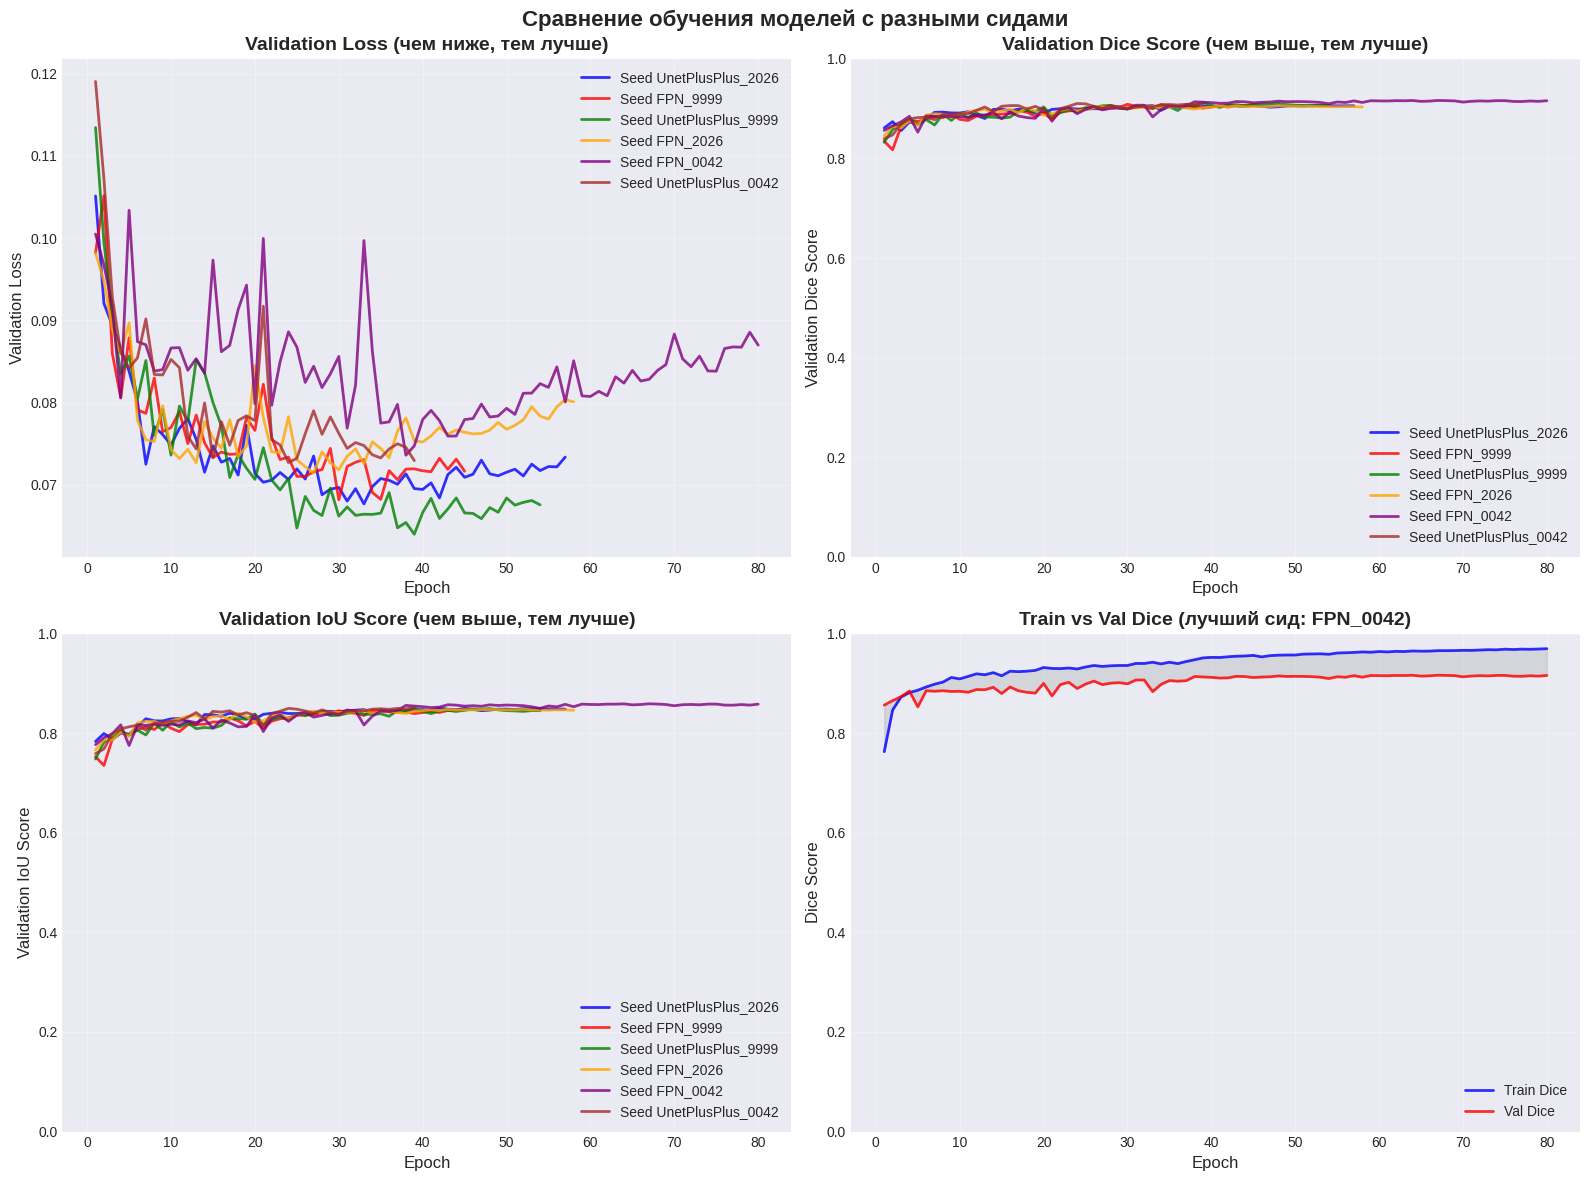


ИТОГОВАЯ СТАТИСТИКА ПО ВСЕМ СИДАМ

Seed UnetPlusPlus_2026:
  Лучший Dice: 0.9070 (эпоха 42)
  Лучший IoU:  0.8503 (эпоха 42)
  Лучший Loss: 0.0677 (эпоха 33)
  Финальный Dice: 0.9056
  Разрыв Train-Val: 0.0545

Seed FPN_9999:
  Лучший Dice: 0.9088 (эпоха 30)
  Лучший IoU:  0.8473 (эпоха 45)
  Лучший Loss: 0.0682 (эпоха 30)
  Финальный Dice: 0.9082
  Разрыв Train-Val: 0.0503

Seed UnetPlusPlus_9999:
  Лучший Dice: 0.9120 (эпоха 39)
  Лучший IoU:  0.8505 (эпоха 39)
  Лучший Loss: 0.0640 (эпоха 39)
  Финальный Dice: 0.9065
  Разрыв Train-Val: 0.0472

Seed FPN_2026:
  Лучший Dice: 0.9058 (эпоха 43)
  Лучший IoU:  0.8483 (эпоха 52)
  Лучший Loss: 0.0714 (эпоха 27)
  Финальный Dice: 0.9034
  Разрыв Train-Val: 0.0583

Seed FPN_0042:
  Лучший Dice: 0.9164 (эпоха 67)
  Лучший IoU:  0.8590 (эпоха 67)
  Лучший Loss: 0.0736 (эпоха 38)
  Финальный Dice: 0.9159
  Разрыв Train-Val: 0.0532

Seed UnetPlusPlus_0042:
  Лучший Dice: 0.9103 (эпоха 24)
  Лучший IoU:  0.8510 (эпоха 39)
  Лучший Loss: 0.0727

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path



print("=" * 60)
print("ПОИСК ФАЙЛОВ ОБУЧЕНИЯ")
print("=" * 60)


seed_dirs = []
for p in Path(".").rglob("history.csv"):
    seed_dirs.append(p.parent)
    print(f"Найден: {p.parent}/history.csv")

if not seed_dirs:
    print("Ошибка")
    print("Сначала запустите обучение с разными сидами")
    exit()


all_data = {}
for seed_dir in seed_dirs:
    history_path = seed_dir / "history.csv"
    df = pd.read_csv(history_path)


    seed_name = seed_dir.name
    if "seed_" in seed_name:
        seed_num = seed_name.replace("seed_", "")
    elif "seed" in seed_name:
        seed_num = seed_name.replace("seed", "")
    else:
        seed_num = seed_name

    all_data[seed_num] = df
    print(f"Загружено {len(df)} эпох для seed {seed_num}")

plt.style.use('seaborn-v0_8-darkgrid')


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Сравнение обучения моделей с разными сидами', fontsize=16, fontweight='bold')


colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']


ax = axes[0, 0]
for idx, (seed_num, df) in enumerate(all_data.items()):
    color = colors[idx % len(colors)]
    ax.plot(df['epoch'], df['val_loss'], color=color, label=f'Seed {seed_num}', linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Validation Loss (чем ниже, тем лучше)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)


ax = axes[0, 1]
for idx, (seed_num, df) in enumerate(all_data.items()):
    color = colors[idx % len(colors)]
    ax.plot(df['epoch'], df['val_dice'], color=color, label=f'Seed {seed_num}', linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Dice Score', fontsize=12)
ax.set_title('Validation Dice Score (чем выше, тем лучше)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])


ax = axes[1, 0]
for idx, (seed_num, df) in enumerate(all_data.items()):
    color = colors[idx % len(colors)]
    ax.plot(df['epoch'], df['val_iou'], color=color, label=f'Seed {seed_num}', linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation IoU Score', fontsize=12)
ax.set_title('Validation IoU Score (чем выше, тем лучше)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])


ax = axes[1, 1]

best_seed = None
best_dice = -1
for seed_num, df in all_data.items():
    max_dice = df['val_dice'].max()
    if max_dice > best_dice:
        best_dice = max_dice
        best_seed = seed_num

if best_seed is not None:
    df_best = all_data[best_seed]
    ax.plot(df_best['epoch'], df_best['train_dice'], 'b-', label='Train Dice', linewidth=2, alpha=0.8)
    ax.plot(df_best['epoch'], df_best['val_dice'], 'r-', label='Val Dice', linewidth=2, alpha=0.8)
    ax.fill_between(df_best['epoch'], df_best['train_dice'], df_best['val_dice'], alpha=0.2, color='gray')
    ax.set_title(f'Train vs Val Dice (лучший сид: {best_seed})', fontsize=14, fontweight='bold')
else:
    ax.set_title('Train vs Val Dice', fontsize=14, fontweight='bold')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Dice Score', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()


save_path = Path("./training_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"\nГрафик сохранен: {save_path}")

plt.show()


print("\n" + "=" * 70)
print("ИТОГОВАЯ СТАТИСТИКА ПО ВСЕМ СИДАМ")
print("=" * 70)

results = []
for seed_num, df in all_data.items():
    best_dice = df['val_dice'].max()
    best_dice_epoch = df['val_dice'].idxmax() + 1
    best_iou = df['val_iou'].max()
    best_iou_epoch = df['val_iou'].idxmax() + 1
    best_loss = df['val_loss'].min()
    best_loss_epoch = df['val_loss'].idxmin() + 1
    final_dice = df['val_dice'].iloc[-1]

    max_train_dice = df['train_dice'].max()
    gap_dice = max_train_dice - best_dice

    results.append({
        'seed': seed_num,
        'best_dice': best_dice,
        'best_dice_epoch': best_dice_epoch,
        'best_iou': best_iou,
        'best_iou_epoch': best_iou_epoch,
        'best_loss': best_loss,
        'best_loss_epoch': best_loss_epoch,
        'final_dice': final_dice,
        'overfitting_gap': gap_dice
    })

    print(f"\nSeed {seed_num}:")
    print(f"  Лучший Dice: {best_dice:.4f} (эпоха {best_dice_epoch})")
    print(f"  Лучший IoU:  {best_iou:.4f} (эпоха {best_iou_epoch})")
    print(f"  Лучший Loss: {best_loss:.4f} (эпоха {best_loss_epoch})")
    print(f"  Финальный Dice: {final_dice:.4f}")
    print(f"  Разрыв Train-Val: {gap_dice:.4f}")


print("\n" + "=" * 70)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ")
print("=" * 70)

best_result = max(results, key=lambda x: x['best_dice'])
print(f"\nЛучшая модель по Dice: Seed {best_result['seed']}")
print(f"  Лучший Dice: {best_result['best_dice']:.4f} (эпоха {best_result['best_dice_epoch']})")
print(f"  Лучший IoU: {best_result['best_iou']:.4f}")
print(f"  Разрыв Train-Val: {best_result['overfitting_gap']:.4f}")

stats_df = pd.DataFrame(results)
stats_csv = Path("./seed_comparison.csv")
stats_df.to_csv(stats_csv, index=False)
print(f"\nСтатистика сохранена: {stats_csv}")


print("\n" + "=" * 70)
print("СОЗДАНИЕ ОТДЕЛЬНЫХ ГРАФИКОВ ДЛЯ КАЖДОГО СИДА")
print("=" * 70)

for seed_num, df in all_data.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Обучение модели (Seed {seed_num})', fontsize=16, fontweight='bold')


    ax = axes[0, 0]
    ax.plot(df['epoch'], df['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax.plot(df['epoch'], df['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax.fill_between(df['epoch'], df['train_loss'], df['val_loss'], alpha=0.2, color='gray')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)


    ax = axes[0, 1]
    ax.plot(df['epoch'], df['train_dice'], 'b-', label='Train Dice', linewidth=2)
    ax.plot(df['epoch'], df['val_dice'], 'r-', label='Val Dice', linewidth=2)
    ax.fill_between(df['epoch'], df['train_dice'], df['val_dice'], alpha=0.2, color='gray')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Dice Score')
    ax.set_title('Dice Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[1, 0]
    ax.plot(df['epoch'], df['train_iou'], 'b-', label='Train IoU', linewidth=2)
    ax.plot(df['epoch'], df['val_iou'], 'r-', label='Val IoU', linewidth=2)
    ax.fill_between(df['epoch'], df['train_iou'], df['val_iou'], alpha=0.2, color='gray')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('IoU Score')
    ax.set_title('IoU Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])


    ax = axes[1, 1]
    ax.plot(df['epoch'], df['lr'], 'g-', linewidth=2)
    ax.fill_between(df['epoch'], 0, df['lr'], alpha=0.2, color='green')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    plt.tight_layout()

    save_path = Path(f"./training_curves_seed_{seed_num}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"График сохранен: {save_path}")

    plt.close()

СРАВНЕНИЕ МОДЕЛЕЙ: UNet++ vs FPN
Найдено UNet++ history: 3
Найдено FPN history: 3

 Лучший UNet++: UnetPlusPlus_seed_9999 (dice=0.9120)
 Лучший FPN: FPN_seed_0042 (dice=0.9164)


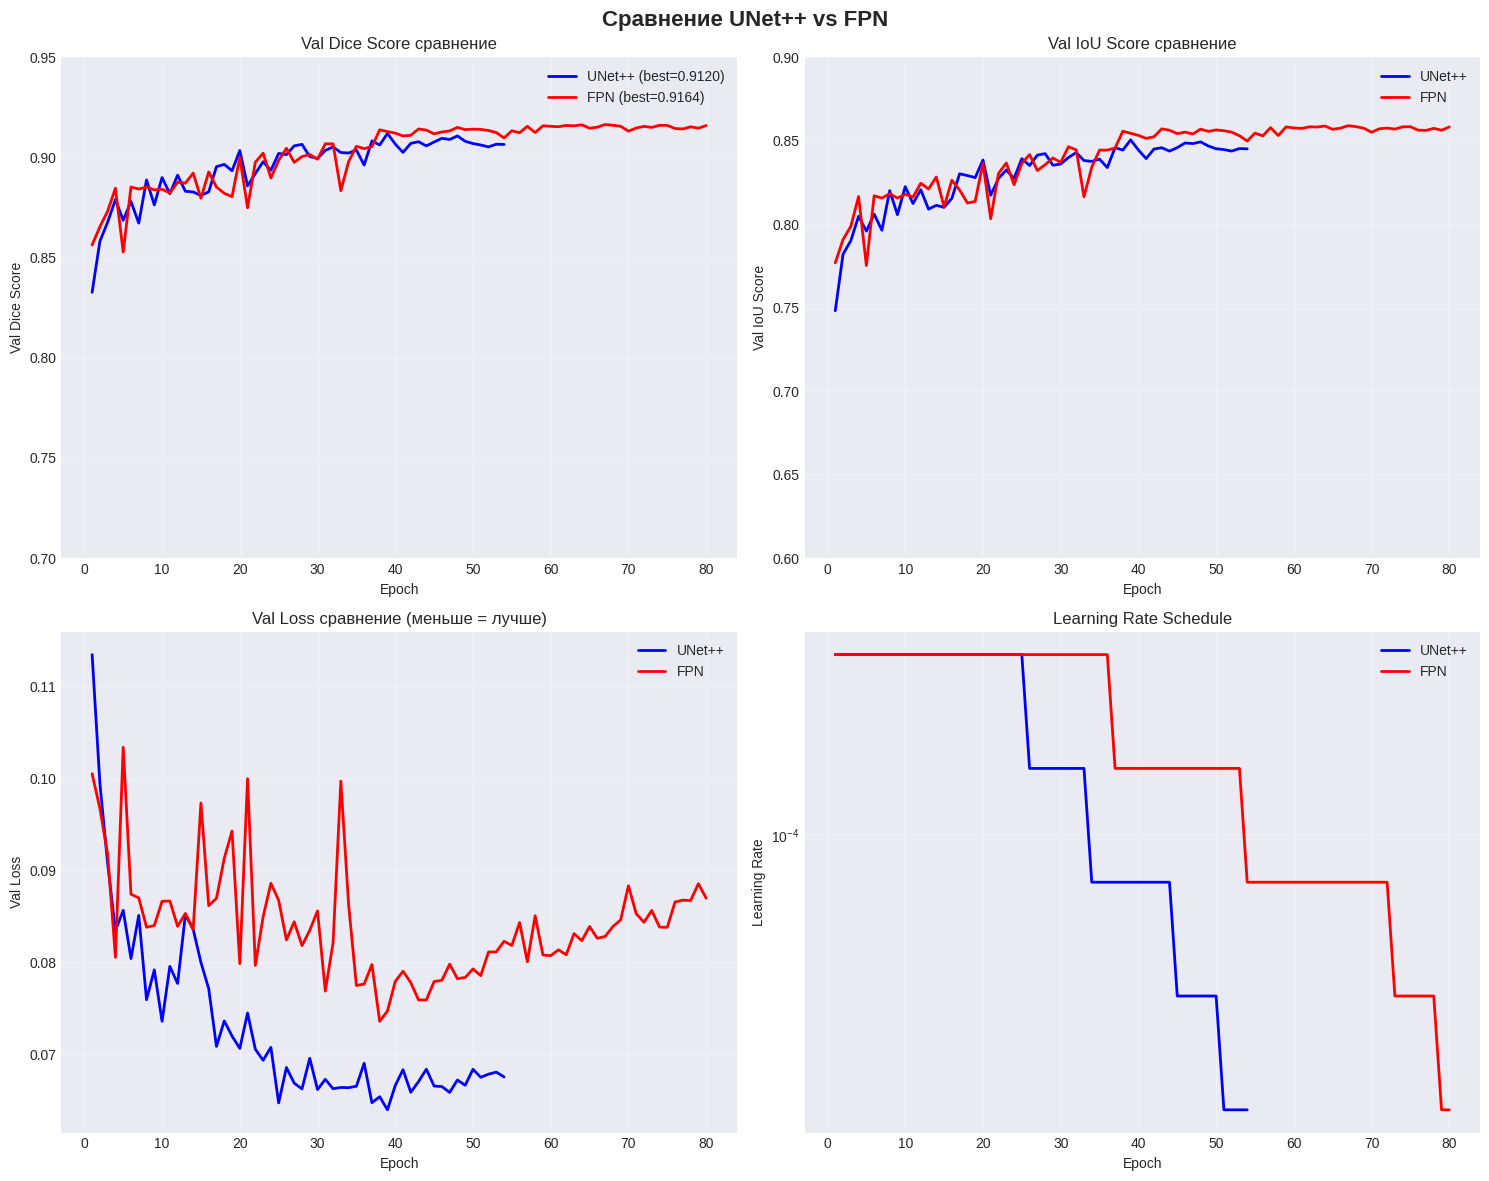


ИТОГОВАЯ СТАТИСТИКА

UNet++:
  Лучший Val Dice: 0.9120 (эпоха 39)
  Лучший Val IoU: 0.8505

FPN:
  Лучший Val Dice: 0.9164 (эпоха 67)
  Лучший Val IoU: 0.8590

✅ FPN показал лучший результат (+0.0045)


In [10]:

print("=" * 70)
print("СРАВНЕНИЕ МОДЕЛЕЙ: UNet++ vs FPN")
print("=" * 70)

import matplotlib.pyplot as plt
from pathlib import Path

SAVE_ROOT = Path("./seg_train_runs")


unet_histories = list(SAVE_ROOT.glob("UnetPlusPlus_seed_*/history.csv"))
fpn_histories = list(SAVE_ROOT.glob("FPN_seed_*/history.csv"))

print(f"Найдено UNet++ history: {len(unet_histories)}")
print(f"Найдено FPN history: {len(fpn_histories)}")

if unet_histories and fpn_histories:

    def get_best_history(histories):
        best_df = None
        best_dice = -1
        best_name = ""
        for h in histories:
            df = pd.read_csv(h)
            max_dice = df['val_dice'].max()
            if max_dice > best_dice:
                best_dice = max_dice
                best_df = df
                best_name = h.parent.name
        return best_df, best_name, best_dice

    best_unet_df, best_unet_name, best_unet_dice = get_best_history(unet_histories)
    best_fpn_df, best_fpn_name, best_fpn_dice = get_best_history(fpn_histories)

    print(f"\n Лучший UNet++: {best_unet_name} (dice={best_unet_dice:.4f})")
    print(f" Лучший FPN: {best_fpn_name} (dice={best_fpn_dice:.4f})")


    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Сравнение UNet++ vs FPN', fontsize=16, fontweight='bold')


    ax = axes[0, 0]
    ax.plot(best_unet_df['epoch'], best_unet_df['val_dice'], 'b-', label=f'UNet++ (best={best_unet_dice:.4f})', linewidth=2)
    ax.plot(best_fpn_df['epoch'], best_fpn_df['val_dice'], 'r-', label=f'FPN (best={best_fpn_dice:.4f})', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Dice Score')
    ax.set_title('Val Dice Score сравнение')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.7, 0.95])


    ax = axes[0, 1]
    ax.plot(best_unet_df['epoch'], best_unet_df['val_iou'], 'b-', label='UNet++', linewidth=2)
    ax.plot(best_fpn_df['epoch'], best_fpn_df['val_iou'], 'r-', label='FPN', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val IoU Score')
    ax.set_title('Val IoU Score сравнение')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.6, 0.9])


    ax = axes[1, 0]
    ax.plot(best_unet_df['epoch'], best_unet_df['val_loss'], 'b-', label='UNet++', linewidth=2)
    ax.plot(best_fpn_df['epoch'], best_fpn_df['val_loss'], 'r-', label='FPN', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Loss')
    ax.set_title('Val Loss сравнение (меньше = лучше)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.plot(best_unet_df['epoch'], best_unet_df['lr'], 'b-', label='UNet++', linewidth=2)
    ax.plot(best_fpn_df['epoch'], best_fpn_df['lr'], 'r-', label='FPN', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    plt.tight_layout()
    plt.savefig("./unet_vs_fpn_comparison.png", dpi=150)
    plt.show()


    print("\n" + "=" * 70)
    print("ИТОГОВАЯ СТАТИСТИКА")
    print("=" * 70)
    print(f"\nUNet++:")
    print(f"  Лучший Val Dice: {best_unet_dice:.4f} (эпоха {best_unet_df['val_dice'].idxmax()+1})")
    print(f"  Лучший Val IoU: {best_unet_df['val_iou'].max():.4f}")
    print(f"\nFPN:")
    print(f"  Лучший Val Dice: {best_fpn_dice:.4f} (эпоха {best_fpn_df['val_dice'].idxmax()+1})")
    print(f"  Лучший Val IoU: {best_fpn_df['val_iou'].max():.4f}")

    if best_unet_dice > best_fpn_dice:
        print(f"\n UNet++ показал лучший результат (+{best_unet_dice - best_fpn_dice:.4f})")
    else:
        print(f"\n FPN показал лучший результат (+{best_fpn_dice - best_unet_dice:.4f})")
else:
    print(" Не найдены файлы history.csv для сравнения")

ПОИСК ФАЙЛОВ ОБУЧЕНИЯ
Найден: seg_train_runs/UnetPlusPlus_seed_2026/history.csv
Найден: seg_train_runs/FPN_seed_9999/history.csv
Найден: seg_train_runs/UnetPlusPlus_seed_9999/history.csv
Найден: seg_train_runs/FPN_seed_2026/history.csv
Найден: seg_train_runs/FPN_seed_0042/history.csv
Найден: seg_train_runs/UnetPlusPlus_seed_0042/history.csv
Загружено 57 эпох для seed UnetPlusPlus_2026
Загружено 45 эпох для seed FPN_9999
Загружено 54 эпох для seed UnetPlusPlus_9999
Загружено 58 эпох для seed FPN_2026
Загружено 80 эпох для seed FPN_0042
Загружено 39 эпох для seed UnetPlusPlus_0042
График сохранен: loss_curves_seed_UnetPlusPlus_2026.png


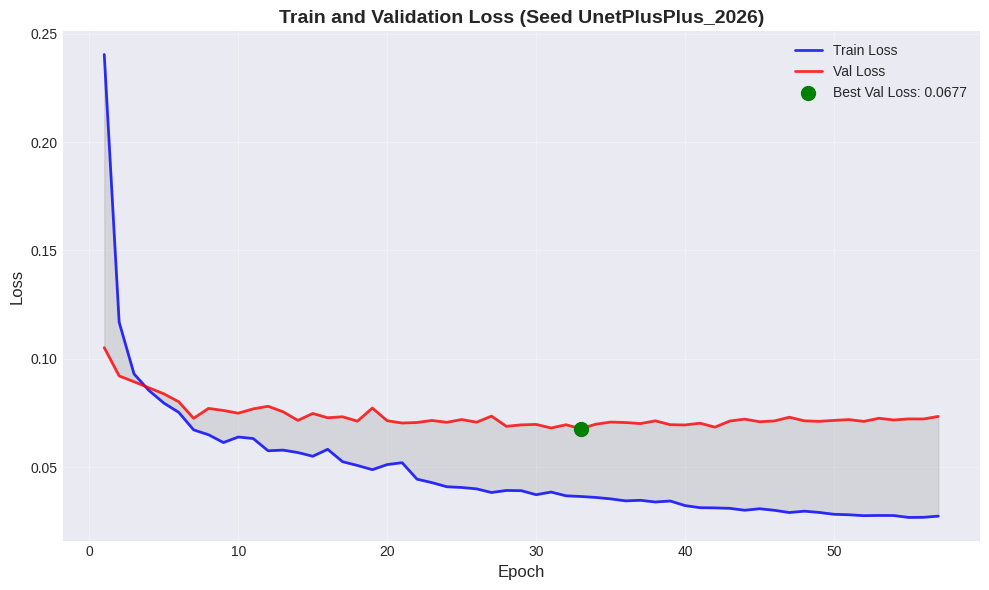

График сохранен: loss_curves_seed_FPN_9999.png


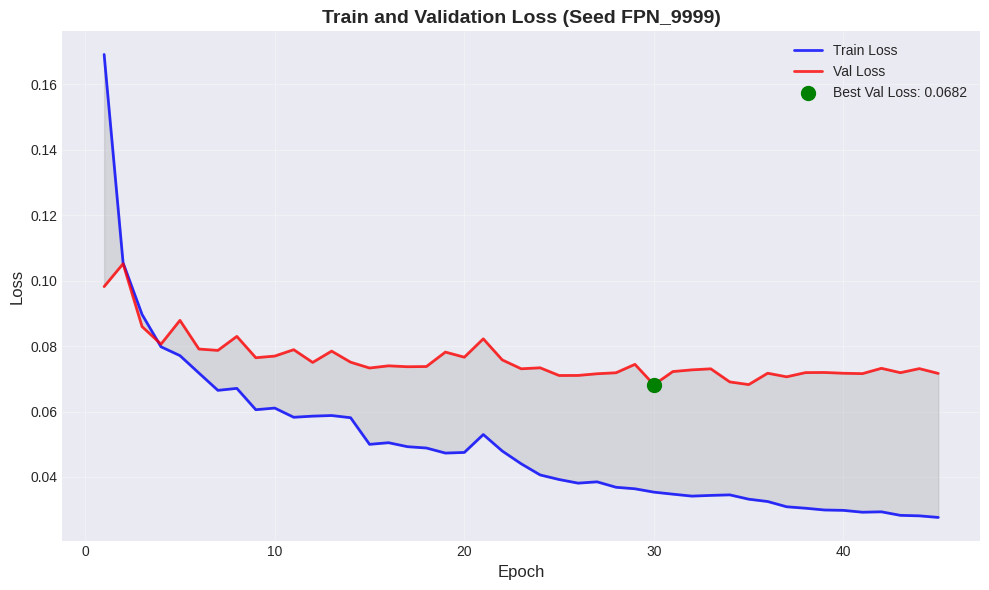

График сохранен: loss_curves_seed_UnetPlusPlus_9999.png


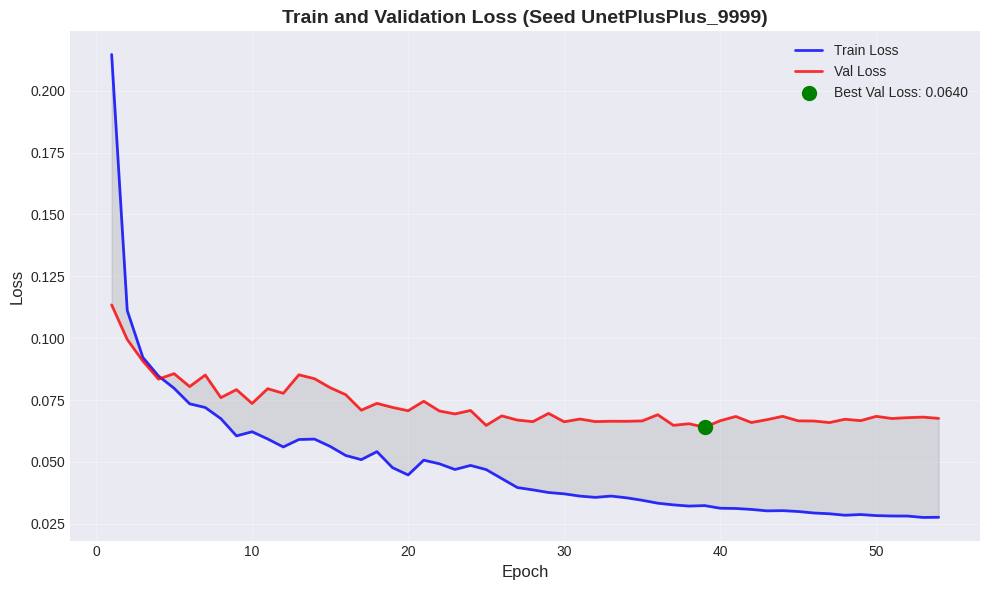

График сохранен: loss_curves_seed_FPN_2026.png


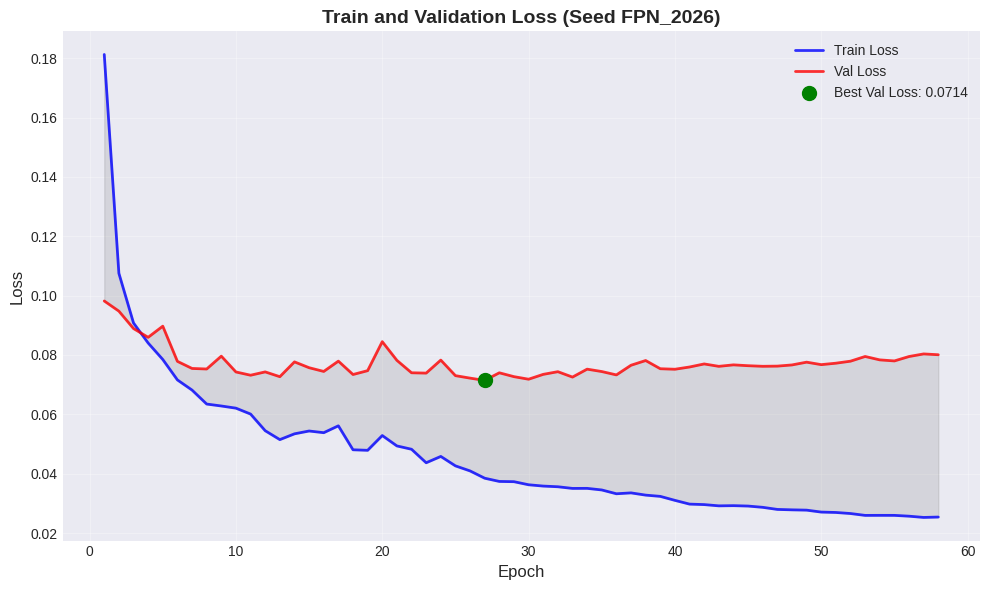

График сохранен: loss_curves_seed_FPN_0042.png


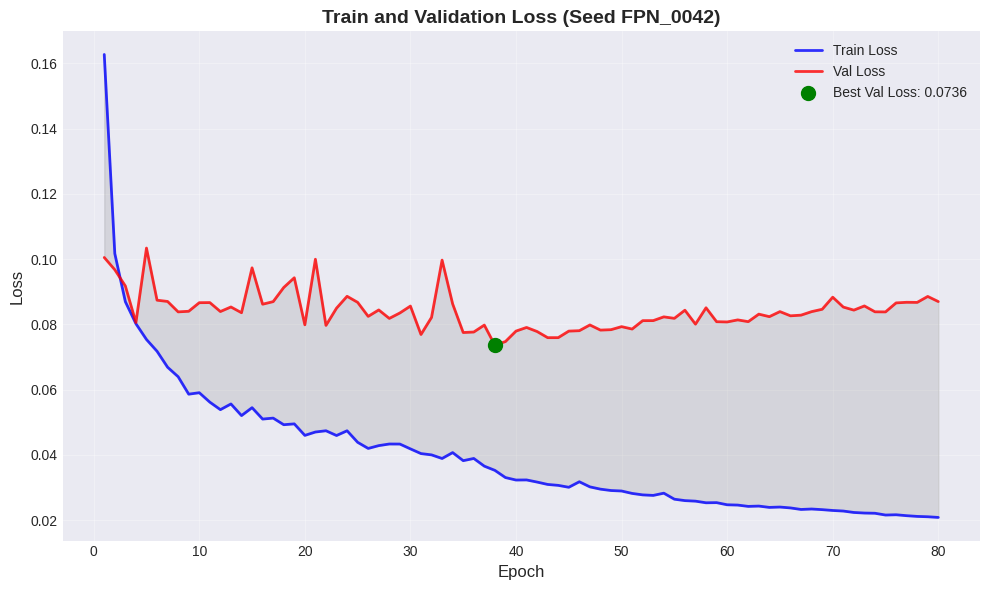

График сохранен: loss_curves_seed_UnetPlusPlus_0042.png


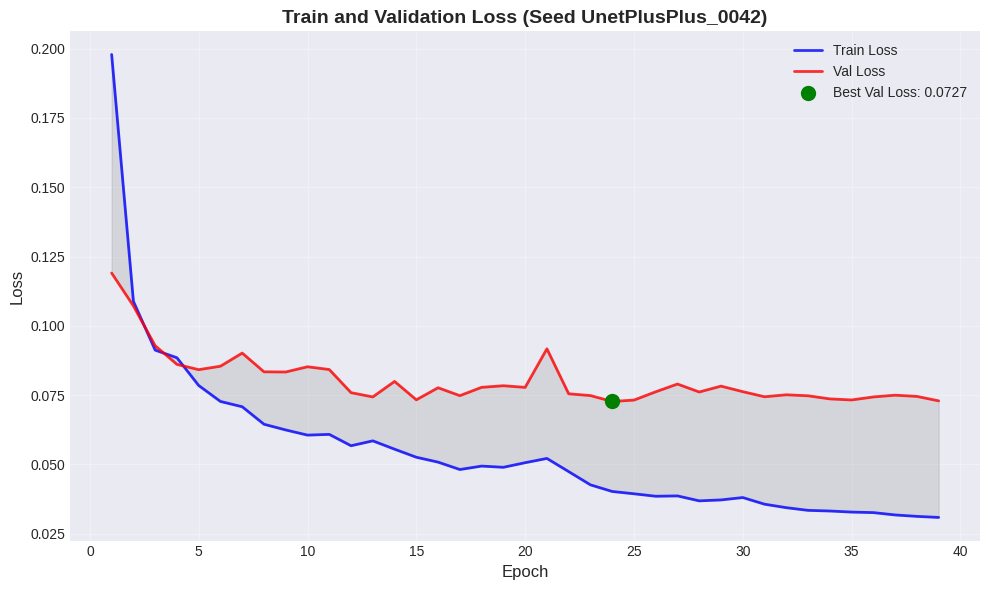


Сводный график сохранен: loss_comparison_all_seeds.png


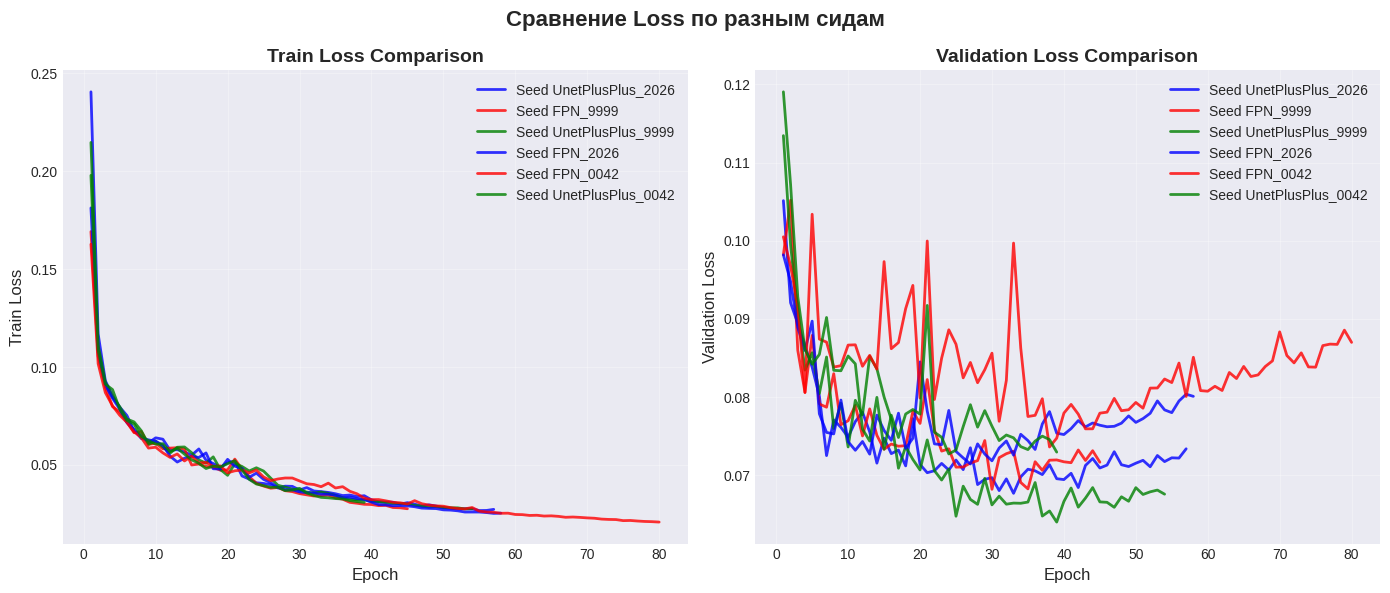


ИТОГОВАЯ СТАТИСТИКА

Seed UnetPlusPlus_2026:
  Лучший Train Loss: 0.0267
  Лучший Val Loss:   0.0677
  Финальный Train Loss: 0.0273
  Финальный Val Loss:   0.0734

Seed FPN_9999:
  Лучший Train Loss: 0.0276
  Лучший Val Loss:   0.0682
  Финальный Train Loss: 0.0276
  Финальный Val Loss:   0.0717

Seed UnetPlusPlus_9999:
  Лучший Train Loss: 0.0275
  Лучший Val Loss:   0.0640
  Финальный Train Loss: 0.0276
  Финальный Val Loss:   0.0676

Seed FPN_2026:
  Лучший Train Loss: 0.0253
  Лучший Val Loss:   0.0714
  Финальный Train Loss: 0.0254
  Финальный Val Loss:   0.0801

Seed FPN_0042:
  Лучший Train Loss: 0.0208
  Лучший Val Loss:   0.0736
  Финальный Train Loss: 0.0208
  Финальный Val Loss:   0.0870

Seed UnetPlusPlus_0042:
  Лучший Train Loss: 0.0309
  Лучший Val Loss:   0.0727
  Финальный Train Loss: 0.0309
  Финальный Val Loss:   0.0729


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path



print("=" * 60)
print("ПОИСК ФАЙЛОВ ОБУЧЕНИЯ")
print("=" * 60)

seed_dirs = []
for p in Path(".").rglob("history.csv"):
    seed_dirs.append(p.parent)
    print(f"Найден: {p.parent}/history.csv")

if not seed_dirs:
    print("ОШИБКА: Не найдено ни одного файла history.csv")
    exit()

all_data = {}
for seed_dir in seed_dirs:
    history_path = seed_dir / "history.csv"
    df = pd.read_csv(history_path)

    seed_name = seed_dir.name
    if "seed_" in seed_name:
        seed_num = seed_name.replace("seed_", "")
    else:
        seed_num = seed_name

    all_data[seed_num] = df
    print(f"Загружено {len(df)} эпох для seed {seed_num}")


plt.style.use('seaborn-v0_8-darkgrid')


for seed_num, df in all_data.items():
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(df['epoch'], df['train_loss'], 'b-', label='Train Loss', linewidth=2, alpha=0.8)
    ax.plot(df['epoch'], df['val_loss'], 'r-', label='Val Loss', linewidth=2, alpha=0.8)
    ax.fill_between(df['epoch'], df['train_loss'], df['val_loss'], alpha=0.2, color='gray')

    best_val_loss_epoch = df['val_loss'].idxmin() + 1
    best_val_loss = df['val_loss'].min()

    ax.scatter(best_val_loss_epoch, best_val_loss, color='green', s=100, zorder=5,
               label=f'Best Val Loss: {best_val_loss:.4f}')

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Train and Validation Loss (Seed {seed_num})', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    save_path = Path(f"./loss_curves_seed_{seed_num}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"График сохранен: {save_path}")

    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Сравнение Loss по разным сидам', fontsize=16, fontweight='bold')

colors = ['blue', 'red', 'green']


ax = axes[0]
for idx, (seed_num, df) in enumerate(all_data.items()):
    color = colors[idx % len(colors)]
    ax.plot(df['epoch'], df['train_loss'], color=color, label=f'Seed {seed_num}', linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Train Loss', fontsize=12)
ax.set_title('Train Loss Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Val Loss
ax = axes[1]
for idx, (seed_num, df) in enumerate(all_data.items()):
    color = colors[idx % len(colors)]
    ax.plot(df['epoch'], df['val_loss'], color=color, label=f'Seed {seed_num}', linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = Path("./loss_comparison_all_seeds.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"\nСводный график сохранен: {save_path}")
plt.show()


print("\n" + "=" * 60)
print("ИТОГОВАЯ СТАТИСТИКА")
print("=" * 60)

for seed_num, df in all_data.items():
    best_train_loss = df['train_loss'].min()
    best_val_loss = df['val_loss'].min()
    final_train_loss = df['train_loss'].iloc[-1]
    final_val_loss = df['val_loss'].iloc[-1]

    print(f"\nSeed {seed_num}:")
    print(f"  Лучший Train Loss: {best_train_loss:.4f}")
    print(f"  Лучший Val Loss:   {best_val_loss:.4f}")
    print(f"  Финальный Train Loss: {final_train_loss:.4f}")
    print(f"  Финальный Val Loss:   {final_val_loss:.4f}")

In [14]:
from pathlib import Path
import shutil
import pandas as pd

OUTPUT_ROOT = Path("/content/all_models")
OUTPUT_ROOT.mkdir(exist_ok=True, parents=True)


models_info = [
    ("UnetPlusPlus", 9999),
    ("UnetPlusPlus", 42),
    ("UnetPlusPlus", 2026),
    ("FPN", 9999),
    ("FPN", 42),
    ("FPN", 2026),
]

print("=" * 60)
print("СБОР МОДЕЛЕЙ И HISTORY.CSV")
print("=" * 60)

copied_models = 0
copied_history = 0

for arch, seed in models_info:

    save_dir = Path(f"/content/seg_train_runs/{arch}_seed_{seed:04d}")

    if not save_dir.exists():

        save_dir = Path(f"/content/seg_train_runs/{arch}_seed_{seed}")

    if not save_dir.exists():
        print(f"\n {arch} seed {seed}: папка не найдена: {save_dir}")
        continue

    best_pth = save_dir / "best.pth"
    last_pth = save_dir / "last.pth"
    history_csv = save_dir / "history.csv"

    print(f"\n {arch} seed {seed}:")
    print(f"   Папка: {save_dir}")


    if best_pth.exists():
        dst = OUTPUT_ROOT / f"best_{arch}_seed_{seed:04d}.pth"
        shutil.copy(best_pth, dst)
        size_mb = best_pth.stat().st_size / 1024 / 1024
        print(f"    best.pth -> {dst.name} ({size_mb:.2f} MB)")
        copied_models += 1
    else:
        print(f"    best.pth не найден")


    if last_pth.exists():
        dst = OUTPUT_ROOT / f"last_{arch}_seed_{seed:04d}.pth"
        shutil.copy(last_pth, dst)
        size_mb = last_pth.stat().st_size / 1024 / 1024
        print(f"    last.pth -> {dst.name} ({size_mb:.2f} MB)")
        copied_models += 1
    else:
        print(f"    last.pth не найден")


    if history_csv.exists():
        dst = OUTPUT_ROOT / f"history_{arch}_seed_{seed:04d}.csv"
        shutil.copy(history_csv, dst)
        print(f"    history.csv -> {dst.name}")

        df = pd.read_csv(history_csv)
        best_dice = df['val_dice'].max()
        best_epoch = df['val_dice'].idxmax() + 1
        best_iou = df['val_iou'].max()
        print(f"      Лучший val_dice: {best_dice:.4f} (эпоха {best_epoch})")
        print(f"      Лучший val_iou: {best_iou:.4f}")
        copied_history += 1
    else:
        print(f"    history.csv не найден")

print(f"\n ИТОГО: скопировано {copied_models} файлов моделей, {copied_history} файлов history.csv")


print("\n" + "=" * 60)
print("СОЗДАНИЕ СВОДНОГО ОТЧЕТА")
print("=" * 60)

summary_data = []

for arch, seed in models_info:
    history_path = OUTPUT_ROOT / f"history_{arch}_seed_{seed:04d}.csv"

    if history_path.exists():
        df = pd.read_csv(history_path)
        summary_data.append({
            'architecture': arch,
            'seed': seed,
            'best_val_dice': df['val_dice'].max(),
            'best_val_dice_epoch': df['val_dice'].idxmax() + 1,
            'best_val_iou': df['val_iou'].max(),
            'best_val_iou_epoch': df['val_iou'].idxmax() + 1,
            'best_val_loss': df['val_loss'].min(),
            'best_val_loss_epoch': df['val_loss'].idxmin() + 1,
            'final_val_dice': df['val_dice'].iloc[-1],
            'final_val_iou': df['val_iou'].iloc[-1],
            'num_epochs': len(df)
        })

if summary_data:
    summary_df = pd.DataFrame(summary_data)
    summary_csv = OUTPUT_ROOT / "all_models_summary.csv"
    summary_df.to_csv(summary_csv, index=False)
    print(f" Сводный отчет сохранен: {summary_csv}")
    print("\n СВОДНАЯ ТАБЛИЦА:")
    print(summary_df.to_string(index=False))


    best_row = summary_df.loc[summary_df['best_val_dice'].idxmax()]
    print(f"\n ЛУЧШАЯ МОДЕЛЬ:")
    print(f"   Архитектура: {best_row['architecture']}")
    print(f"   Seed: {best_row['seed']}")
    print(f"   Best val_dice: {best_row['best_val_dice']:.4f} (эпоха {best_row['best_val_dice_epoch']})")
    print(f"   Best val_iou: {best_row['best_val_iou']:.4f}")
else:
    print(" Не найдено ни одного history.csv для создания отчета")


import zipfile

zip_path = OUTPUT_ROOT / "all_models.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for file in OUTPUT_ROOT.iterdir():
        if file.is_file() and file.suffix in ['.pth', '.csv']:
            zipf.write(file, arcname=file.name)
            print(f"   Добавлен: {file.name}")

print(f"\n Архив создан: {zip_path}")
print(f" Размер архива: {zip_path.stat().st_size / 1024 / 1024:.2f} MB")

СБОР МОДЕЛЕЙ И HISTORY.CSV

 UnetPlusPlus seed 9999:
   Папка: /content/seg_train_runs/UnetPlusPlus_seed_9999
    best.pth -> best_UnetPlusPlus_seed_9999.pth (152.24 MB)
    last.pth -> last_UnetPlusPlus_seed_9999.pth (152.24 MB)
    history.csv -> history_UnetPlusPlus_seed_9999.csv
      Лучший val_dice: 0.9120 (эпоха 39)
      Лучший val_iou: 0.8505

 UnetPlusPlus seed 42:
   Папка: /content/seg_train_runs/UnetPlusPlus_seed_0042
    best.pth -> best_UnetPlusPlus_seed_0042.pth (152.24 MB)
    last.pth -> last_UnetPlusPlus_seed_0042.pth (152.24 MB)
    history.csv -> history_UnetPlusPlus_seed_0042.csv
      Лучший val_dice: 0.9103 (эпоха 24)
      Лучший val_iou: 0.8510

 UnetPlusPlus seed 2026:
   Папка: /content/seg_train_runs/UnetPlusPlus_seed_2026
    best.pth -> best_UnetPlusPlus_seed_2026.pth (152.24 MB)
    last.pth -> last_UnetPlusPlus_seed_2026.pth (152.24 MB)
    history.csv -> history_UnetPlusPlus_seed_2026.csv
      Лучший val_dice: 0.9070 (эпоха 42)
      Лучший val_iou: 0

In [15]:
from google.colab import files
files.download('/content/all_models/all_models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>